# Propensity Weighting Pipeline

## Load Data

In [1]:
# ── Packages ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pymatchit import MatchIt

# ── Read from local Excel file ─────────────────────────────────────────────
FILE = '../data/qualtrics.xlsx'

s1 = pd.read_excel(FILE, sheet_name='survey_1')
s2 = pd.read_excel(FILE, sheet_name='survey_2')
s3 = pd.read_excel(FILE, sheet_name='survey_3')
s4 = pd.read_excel(FILE, sheet_name='participants')[['PROLIFIC_PID', 'GROUP']]

In [2]:
# ── Correct GAAIS column names ─────────────────────────────────────────────
correct_names = [
    'GAAIS_1',  'GAAIS_2',  'GAAIS_3',  'ATT_1',   'GAAIS_4',
    'GAAIS_5',  'GAAIS_6',  'GAAIS_7',  'GAAIS_8',  'GAAIS_9',
    'ATT_2',    'GAAIS_10', 'GAAIS_11', 'GAAIS_12', 'GAAIS_13',
    'GAAIS_14', 'GAAIS_15', 'GAAIS_16', 'GAAIS_17', 'GAAIS_18',
    'ATT_3',    'GAAIS_19', 'GAAIS_20'
]

# Rename by position
def rename_cols_by_position(df, start, end, new_names):
    cols = df.columns.tolist()
    cols[start:end] = new_names
    df.columns = cols
    return df

s1 = rename_cols_by_position(s1, 15, 38, correct_names)
s2 = rename_cols_by_position(s2, 10, 33, correct_names)
s3 = rename_cols_by_position(s3, 2, 25, correct_names)

In [3]:
# ── Build df_long ──────────────────────────────────────────────────────────
valid_pids = s3['PROLIFIC_PID'].unique()

df_long = pd.concat([
    s1[s1['PROLIFIC_PID'].isin(valid_pids)].assign(time=1),
    s2[s2['PROLIFIC_PID'].isin(valid_pids)].assign(time=2),
    s3[s3['PROLIFIC_PID'].isin(valid_pids)].assign(time=3)
], ignore_index=True)
df_long = df_long.merge(s4, on='PROLIFIC_PID', how='left')

likert_recode = {
    'Strongly Disagree':          1,
    'Disagree':                   2,
    'Somewhat disagree':          3,
    'Neither agree nor disagree': 4,
    'Somewhat agree':             5,
    'Agree':                      6,
    'Strongly agree':             7
}

gaais_cols = [f'GAAIS_{i}' for i in range(1, 21)]
neg_items  = ['GAAIS_3','GAAIS_6','GAAIS_8','GAAIS_9',
               'GAAIS_10','GAAIS_15','GAAIS_19','GAAIS_20']
pos_items  = ['GAAIS_1','GAAIS_2','GAAIS_4','GAAIS_5','GAAIS_7',
               'GAAIS_11','GAAIS_12','GAAIS_13','GAAIS_14',
               'GAAIS_16','GAAIS_17','GAAIS_18']

# Recode text -> numbers
df_long[gaais_cols] = df_long[gaais_cols].replace(likert_recode)
df_long[gaais_cols] = df_long[gaais_cols].apply(pd.to_numeric, errors='coerce')

# Reverse-code negative items (8 - x)
df_long[neg_items] = 8 - df_long[neg_items]

# GAAIS total (row sum)
df_long['GAAIS_total'] = df_long[gaais_cols].sum(axis=1, skipna=True)

df_long.head()

,StartDate,EndDate,C1,C2_1,C2_2,C2_3,C2_4,C2_5,C3,C4,...,K3,K4,K5,SC0,SC1,HistoryCheck,Knowledge Score,Attention Score,GROUP,GAAIS_total
0,2026-02-05 15:11:33,2026-02-05 15:15:31,Yes,Not at all,Every Day,Every Day,Nearly Every Day,Several days,Yes,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,treatment,55
1,2026-02-05 18:33:34,2026-02-05 18:40:29,Yes,Nearly Every Day,Several days,Several days,Every Day,Several days,Yes,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,treatment,40
2,2026-02-05 18:36:33,2026-02-05 18:47:41,Yes,More than half the days,More than half the days,Not at all,Nearly Every Day,Several days,Yes,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,control,86
3,2026-02-09 14:19:45,2026-02-09 14:24:18,Yes,Every Day,Nearly Every Day,Every Day,Every Day,Every Day,Yes,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,control,139
4,2026-02-09 14:17:14,2026-02-09 14:25:21,Yes,Not at all,Every Day,Every Day,Every Day,Nearly Every Day,Yes,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,control,70


In [4]:
# ── Build propensity_df ──────────────────────────────────────────────────────────
d_cols = [f"D{i}" for i in range(1, 9)] # demographic cols

propensity_df = (
    df_long[df_long["time"] == 1] # only want GAAIS from s1
    [["PROLIFIC_PID", "GROUP"] + d_cols + ["GAAIS_total"]]
    .copy()
)

propensity_df["GROUP"] = (
    propensity_df["GROUP"]
    .map({"control": 0, "treatment": 1})
    .astype(int)
)

propensity_df.head()

,PROLIFIC_PID,GROUP,D1,D2,D3,D4,D5,D6,D7,D8,GAAIS_total
0,c8ad8a2fad68902c8b205bb5079216a489da0164758a6b...,1,30-49,Male,White,No,"Less than $30,000",Suburban,Bachelor’s degree,An Independent,55
1,e493ee367fde2db65ccd50297141fdcc1815bf2b4f1707...,1,30-49,Male,White,No,"Less than $30,000",Suburban,High school graduate or equivalent (e.g. GED),A Democrat,40
2,24e97a36f51885a54c77be79cc5614c918133f7eba983e...,0,18-29,Male,White,No,"$30,000 - $69,999",Suburban,Graduate or Professional degree,An Independent,86
3,4c702f1bd58b7e542476873c4b41f6170fdb954822b14b...,0,30-49,Male,Other,Yes,"$70,000 - $99,999",Urban,Graduate or Professional degree,A Republican,139
4,3a8ebbb6cc59503cf21552096af6abfd4b6321cbaad371...,0,30-49,Female,White,No,"$100,000+",Suburban,Bachelor’s degree,A Democrat,70


In [5]:
# ── Append YT pre-exposure behaviour data to df ──────────────────────────────────────────────────────────
pre_behavior = pd.read_csv("../data/pre_history_b_results.csv")
pre_behavior = (
    pre_behavior[
        [
            "participant_id",
            "total_adjusted_videos",
            "total_adjusted_watch_time",
        ]
    ]
    .rename(columns={
        "total_adjusted_videos": "pre_total_videos",
        "total_adjusted_watch_time": "pre_total_watch_time",
    })
    .drop_duplicates(subset="participant_id")
)

propensity_df = propensity_df.merge(
    pre_behavior,
    left_on="PROLIFIC_PID",
    right_on="participant_id",
    how="left",
    validate="one_to_one",
).drop(columns="participant_id")

propensity_df.head()

,PROLIFIC_PID,GROUP,D1,D2,D3,D4,D5,D6,D7,D8,GAAIS_total,pre_total_videos,pre_total_watch_time
0,c8ad8a2fad68902c8b205bb5079216a489da0164758a6b...,1,30-49,Male,White,No,"Less than $30,000",Suburban,Bachelor’s degree,An Independent,55,18,22001.750
1,e493ee367fde2db65ccd50297141fdcc1815bf2b4f1707...,1,30-49,Male,White,No,"Less than $30,000",Suburban,High school graduate or equivalent (e.g. GED),A Democrat,40,595,185916.641
2,24e97a36f51885a54c77be79cc5614c918133f7eba983e...,0,18-29,Male,White,No,"$30,000 - $69,999",Suburban,Graduate or Professional degree,An Independent,86,1176,86727.433
3,4c702f1bd58b7e542476873c4b41f6170fdb954822b14b...,0,30-49,Male,Other,Yes,"$70,000 - $99,999",Urban,Graduate or Professional degree,A Republican,139,85,76754.517
4,3a8ebbb6cc59503cf21552096af6abfd4b6321cbaad371...,0,30-49,Female,White,No,"$100,000+",Suburban,Bachelor’s degree,A Democrat,70,625,156887.672


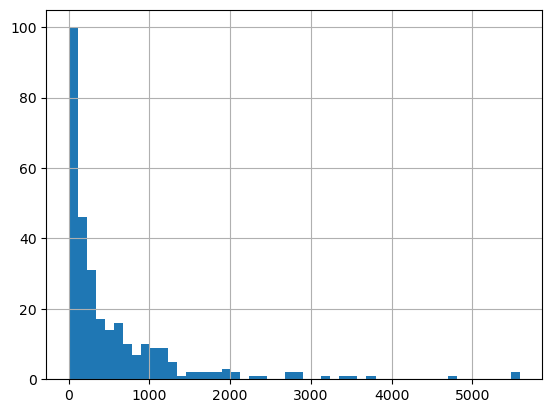

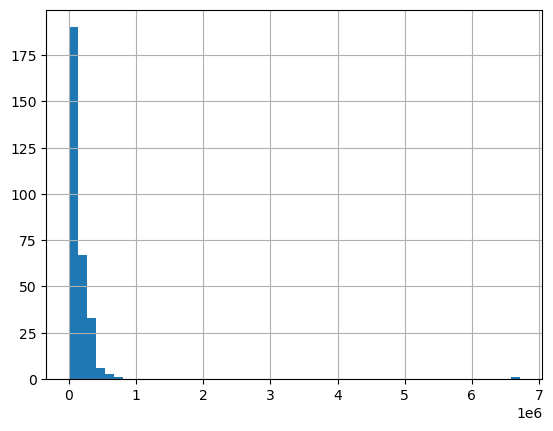

In [6]:
# ── Check distribution of YT behavioural metrics ──────────────────────────────────────────────────────────
# quite skewed --> better to log these metrics
propensity_df["pre_total_videos"].hist(bins=50)
plt.show()

propensity_df["pre_total_watch_time"].hist(bins=50)
plt.show()

In [7]:
# ── Log-transform those two columns ──────────────────────────────────────────────────────────
propensity_df["log_pre_total_videos"] = np.log1p(
    propensity_df["pre_total_videos"]
)

propensity_df["log_pre_total_watch_time"] = np.log1p(
    propensity_df["pre_total_watch_time"]
)

propensity_df.head()

,PROLIFIC_PID,GROUP,D1,D2,D3,D4,D5,D6,D7,D8,GAAIS_total,pre_total_videos,pre_total_watch_time,log_pre_total_videos,log_pre_total_watch_time
0,c8ad8a2fad68902c8b205bb5079216a489da0164758a6b...,1,30-49,Male,White,No,"Less than $30,000",Suburban,Bachelor’s degree,An Independent,55,18,22001.750,2.944439,9.998923
1,e493ee367fde2db65ccd50297141fdcc1815bf2b4f1707...,1,30-49,Male,White,No,"Less than $30,000",Suburban,High school graduate or equivalent (e.g. GED),A Democrat,40,595,185916.641,6.390241,12.133059
2,24e97a36f51885a54c77be79cc5614c918133f7eba983e...,0,18-29,Male,White,No,"$30,000 - $69,999",Suburban,Graduate or Professional degree,An Independent,86,1176,86727.433,7.070724,11.370537
3,4c702f1bd58b7e542476873c4b41f6170fdb954822b14b...,0,30-49,Male,Other,Yes,"$70,000 - $99,999",Urban,Graduate or Professional degree,A Republican,139,85,76754.517,4.454347,11.248381
4,3a8ebbb6cc59503cf21552096af6abfd4b6321cbaad371...,0,30-49,Female,White,No,"$100,000+",Suburban,Bachelor’s degree,A Democrat,70,625,156887.672,6.439350,11.963292


In [8]:
# ── Verify that we have all participants ──────────────────────────────────────────────────────────
# expect 301 participants in total; 166 in treatment, 135 in control
propensity_df["GROUP"].value_counts()

GROUP
1    166
0    135
Name: count, dtype: int64

## Compute Propensity Scores
Using Python's port of [Matchit](https://pypi.org/project/pymatchit-causal/) to compute propensity scores

In [9]:
m = MatchIt(
    data=propensity_df,
    method='nearest',          
    distance='glm',   
    caliper={'distance': 0.03},
    replace=False,
    random_state=42
)

# D1: age, D2: gender, D7: education, D8: political party
formula = (
    "GROUP ~ D1 + D2 + D7 + D8 + GAAIS_total + log_pre_total_videos + log_pre_total_watch_time"
)


m.fit(formula)

Performing nearest matching (ATT)...
Matching complete. 228 observations in matched set.


MatchIt(method='nearest', distance='glm', estimand='ATT', status='fitted', n_matched=228)

## Compute Stablilized Weights

In [10]:
p_treatment = 166 / 301
p_control = 135 / 301

full_data_with_scores = m.data
full_data_with_scores["stabilized_weight"] = np.where(
    full_data_with_scores["GROUP"] == 1,
    p_treatment / full_data_with_scores["propensity_score"],
    p_control / (1 - full_data_with_scores["propensity_score"])
)

## Assess balance

In [11]:
# ── Functions for weighted means / variances / SMDs ──────────────────────────────────────────────────────────
def weighted_mean(x, w):
    return np.sum(w * x) / np.sum(w)


def weighted_var(x, w):
    mean = weighted_mean(x, w)

    return np.sum(
        w * (x - mean) ** 2
    ) / np.sum(w)


def smd(data, variable, treatment="GROUP", weights=None):

    treated = data[treatment] == 1
    control = data[treatment] == 0

    x_t = data.loc[treated, variable].astype(float)
    x_c = data.loc[control, variable].astype(float)

    var_t = x_t.var(ddof=0)
    var_c = x_c.var(ddof=0)

    if weights is None:
        mean_t = x_t.mean()
        mean_c = x_c.mean()
    else:
        w_t = data.loc[treated, weights].astype(float)
        w_c = data.loc[control, weights].astype(float)

        mean_t = weighted_mean(x_t, w_t)
        mean_c = weighted_mean(x_c, w_c)

    pooled_sd = np.sqrt((var_t + var_c) / 2)

    if pooled_sd == 0:
        return 0

    return (mean_t - mean_c) / pooled_sd

In [12]:
# ── Prepare covariates ──────────────────────────────────────────────────────────
categorical_covariates = ["D1", "D2", "D7", "D8"]
continuous_covariates = [
    "GAAIS_total",
    "log_pre_total_videos",
    "log_pre_total_watch_time"
]

balance_data = full_data_with_scores[
    [
        "GROUP",
        "stabilized_weight",
        *categorical_covariates,
        *continuous_covariates
    ]
].copy()


# Dummy-code categorical variables
# drop_first=False because for balance diagnostics it is useful
# to examine every category separately.
balance_data = pd.get_dummies(
    balance_data,
    columns=categorical_covariates,
    drop_first=False,
    dtype=float
)


# All columns to assess balance on
covariates = [
    col
    for col in balance_data.columns
    if col not in ["GROUP", "stabilized_weight"]
]

In [13]:
# ── Calculate unweighted and weighted SMDs ──────────────────────────────────────────────────────────

balance_results = []

for var in covariates:

    unweighted_smd = smd(
        balance_data,
        variable=var,
        treatment="GROUP",
        weights=None
    )

    weighted_smd = smd(
        balance_data,
        variable=var,
        treatment="GROUP",
        weights="stabilized_weight"
    )

    balance_results.append({
        "variable": var,
        "unweighted_smd": unweighted_smd,
        "weighted_smd": weighted_smd,
        "abs_unweighted_smd": abs(unweighted_smd),
        "abs_weighted_smd": abs(weighted_smd)
    })


balance_df = pd.DataFrame(balance_results)

In [14]:
# ── Create labels for love plot ──────────────────────────────────────────────────────────
label_map = {
    "GAAIS_total": "Baseline GAAIS",
    "log_pre_total_videos": "Pre-period video count",
    "log_pre_total_watch_time": "Pre-period watch time",

    "D1_18-29": "Age: 18–29",
    "D1_30-49": "Age: 30–49",
    "D1_50-64": "Age: 50–64",
    "D1_65+": "Age: 65+",

    "D2_Female": "Gender: Female",
    "D2_Male": "Gender: Male",

    "D7_Bachelor’s degree": "Education: Bachelor's",
    "D7_Graduate or Professional degree": "Education: Graduate/professional",
    "D7_High school graduate or equivalent (e.g. GED)": "Education: High school",
    "D7_Less than high school": "Education: < High school",
    "D7_Some college, no degree": "Education: Some college",

    "D8_A Democrat": "Political affiliation: Democrat",
    "D8_A Republican": "Political affiliation: Republican",
    "D8_An Independent": "Political affiliation: Independent",
    "D8_Something else": "Political affiliation: Other"
}

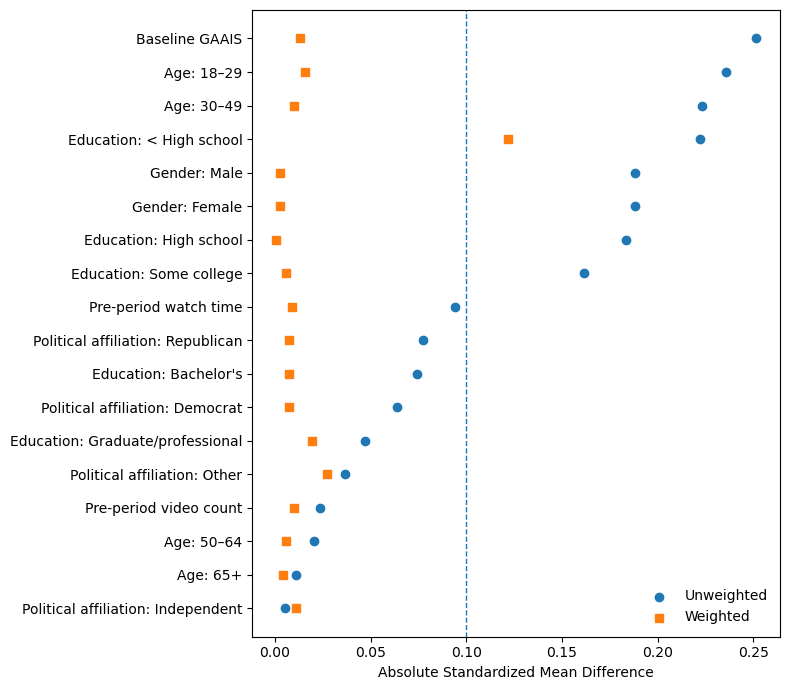

In [15]:
# ── Create love plot to assess balance ──────────────────────────────────────────────────────────
plot_df = balance_df.sort_values(
    "abs_unweighted_smd",
    ascending=True
)
plot_df["label"] = plot_df["variable"].map(label_map).fillna(
    plot_df["variable"]
)

y = np.arange(len(plot_df))

plt.figure(figsize=(8, 7))

plt.scatter(
    plot_df["abs_unweighted_smd"],
    y,
    marker="o",
    label="Unweighted"
)

plt.scatter(
    plot_df["abs_weighted_smd"],
    y,
    marker="s",
    label="Weighted"
)

# Common threshold for acceptable balance
plt.axvline(
    x=0.1,
    linestyle="--",
    linewidth=1
)

plt.yticks(
    y,
    plot_df["label"]
)

plt.xlabel("Absolute Standardized Mean Difference")
plt.ylabel("")

plt.legend(
    frameon=False
)

plt.tight_layout()

plt.savefig(
    "../figures/smd_love_plot.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

## Save to File

In [16]:
# save sample from propensity MATCHING
matched_df = m.matched_data
matched_df[["PROLIFIC_PID", "GROUP"]].to_csv(
    "../data/propensity_matched_ids.csv",
    index=False
)
# save weights from stabilized propensity WEIGHTING
full_data_with_scores[["PROLIFIC_PID", "GROUP", "propensity_score", "stabilized_weight"]].to_csv(
    "../data/full_data_with_propensity_scores.csv",
    index=False
)